In [24]:
import re
import matplotlib.pyplot as plt
import string
from nltk.corpus import stopwords
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize.treebank import TreebankWordDetokenizer
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import gensim
from sklearn.model_selection import train_test_split
import spacy
import pickle
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt 
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
print('Done')

from importlib import reload
import prepare_data as pda
reload(pda)

Done


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dhaaa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dhaaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<module 'prepare_data' from 'c:\\Users\\dhaaa\\OneDrive\\Skrivebord\\Skole\\Gruppe INFO284\\Info284\\prepare_data.py'>

In [2]:
print(tf.config.list_physical_devices('GPU'))

[]


In [3]:
print(tf.version)

<module 'tensorflow._api.v2.version' from 'c:\\Users\\dhaaa\\anaconda3\\Lib\\site-packages\\tensorflow\\_api\\v2\\version\\__init__.py'>


In [4]:
train = pd.read_csv('./data/Hotel_Reviews.csv')

In [5]:
len(train)

515738

In [6]:
X = pda.combine_reviews(train)
y = pda.target_score_to_expression(train)

In [7]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))  # deacc=True removes punctuations
        

data_words = list(sent_to_words(X))

print(data_words[:10])

[['angry', 'made', 'post', 'available', 'via', 'possible', 'site', 'use', 'planing', 'trip', 'one', 'make', 'mistake', 'booking', 'place', 'made', 'booking', 'via', 'booking', 'com', 'stayed', 'night', 'hotel', 'july', 'upon', 'arrival', 'placed', 'small', 'room', 'nd', 'floor', 'hotel', 'turned', 'room', 'booked', 'specially', 'reserved', 'level', 'duplex', 'room', 'would', 'big', 'window', 'high', 'ceiling', 'room', 'ok', 'mind', 'broken', 'window', 'closed', 'hello', 'rain', 'mini', 'fridge', 'contained', 'sort', 'bio', 'weapon', 'least', 'guessed', 'smell', 'intimately', 'asked', 'change', 'room', 'explaining', 'time', 'booked', 'duplex', 'btw', 'cost', 'simple', 'double', 'got', 'way', 'volume', 'due', 'high', 'ceiling', 'offered', 'room', 'next', 'day', 'check', 'next', 'day', 'clock', 'order', 'get', 'room', 'waned', 'best', 'way', 'begin', 'holiday', 'wait', 'till', 'order', 'check', 'new', 'room', 'wonderful', 'waist', 'time', 'room', 'got', 'wanted', 'peaceful', 'internal', '

In [8]:
len(data_words)

515738

In [9]:
def detokenize(text):
    return TreebankWordDetokenizer().detokenize(text)

In [10]:
data = []
for i in range(len(data_words)):
    data.append(detokenize(data_words[i]))
print(data[:5])

['angry made post available via possible site use planing trip one make mistake booking place made booking via booking com stayed night hotel july upon arrival placed small room nd floor hotel turned room booked specially reserved level duplex room would big window high ceiling room ok mind broken window closed hello rain mini fridge contained sort bio weapon least guessed smell intimately asked change room explaining time booked duplex btw cost simple double got way volume due high ceiling offered room next day check next day clock order get room waned best way begin holiday wait till order check new room wonderful waist time room got wanted peaceful internal garden view big window tired waiting room placed belonging rushed city evening turned constant noise room guess made vibrating vent tube something constant annoying hell stop even making hard fall asleep wife audio recording attach want send via mail next day technician came able determine cause disturbing sound offered change ro

In [11]:
data = np.array(data)

In [ ]:
labels = np.array(y)
y = []
for i in range(len(labels)):
    if labels[i] == 'neutral':
        y.append(0)
    if labels[i] == 'negative':
        y.append(1)
    if labels[i] == 'positive':
        y.append(2)
y = np.array(y)
labels = tf.keras.utils.to_categorical(y, num_classes=3)
del y

In [13]:
len(labels)

515738

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import RMSprop,Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint
max_words = 5000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(data)
sequences = tokenizer.texts_to_sequences(data)
reviews = pad_sequences(sequences, maxlen=max_len)
print(reviews)

[[  0   0   0 ... 124   3 101]
 [  0   0   0 ...  72 384 318]
 [  0   0   0 ...  12 102  72]
 ...
 [  0   0   0 ...  93  80  30]
 [  0   0   0 ...  24  58 151]
 [  0   0   0 ... 656   2 219]]


In [15]:
print(labels)

[[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(reviews, labels, random_state=0)
print (len(X_train),len(X_test),len(y_train),len(y_test))

386803 128935 386803 128935


In [ ]:
with tf.device('/GPU:0'):
    model1 = Sequential()
    model1.add(layers.Embedding(max_words, 20))
    model1.add(layers.LSTM(20,dropout=0.5))
    model1.add(layers.Dense(3,activation='softmax'))


    model1.compile(optimizer='adamax',loss='categorical_crossentropy', metrics=['accuracy'])
    #Implementing model checkpoins to save the best metric and do not lose it on training.
    checkpoint1 = ModelCheckpoint("best_model1.keras", monitor='val_accuracy', verbose=1,save_best_only=True, mode='auto',save_weights_only=False)
    history = model1.fit(X_train, y_train, epochs=10, batch_size=512,validation_data=(X_test, y_test),callbacks=[checkpoint1])

Epoch 1/10
 32/756 ━━━━━━━━━━━━━━━━━━━━ 5:21 444ms/step - accuracy: 0.6089 - loss: 0.9363

KeyboardInterrupt: 

In [18]:
#Let's load the best model obtained during training
best_model = keras.models.load_model("best_model1.keras")

In [19]:
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=2)
print('Model accuracy: ',test_acc)

4030/4030 - 29s - 7ms/step - accuracy: 0.7703 - loss: 0.5139
Model accuracy:  0.7702718377113342


In [20]:
predictions = best_model.predict(X_test)

4030/4030 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step


In [ ]:
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_test.argmax(axis=1), np.around(predictions, decimals=0).argmax(axis=1))

[[29990     0 12275]
 [ 2370     0   303]
 [14801     0 69196]]


In [27]:
print(classification_report(np.argmax(y_test, axis=1), np.argmax(predictions, axis=1)))

              precision    recall  f1-score   support

           0       0.64      0.70      0.67     42265
           1       0.00      0.00      0.00      2673
           2       0.84      0.83      0.84     83997

    accuracy                           0.77    128935
   macro avg       0.49      0.51      0.50    128935
weighted avg       0.76      0.77      0.76    128935



<Axes: >

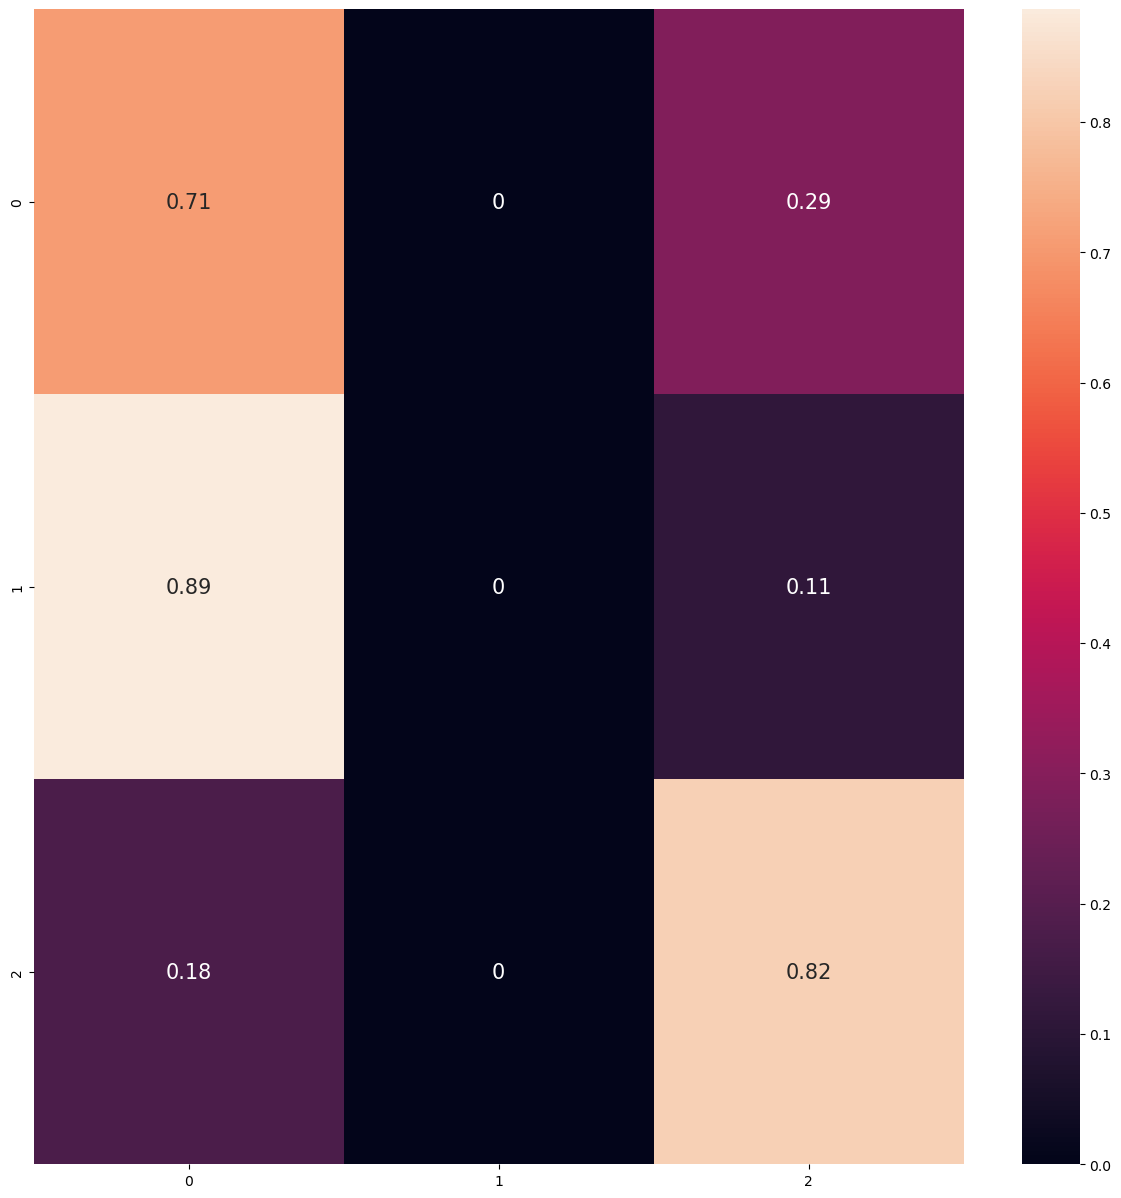

In [22]:
import seaborn as sns
conf_matrix = pd.DataFrame(matrix, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
#Normalizing
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis=1)[:, np.newaxis]
plt.figure(figsize = (15,15))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 15})